# 24 — Local Qwen3 8B End-to-End Smoke Test

**Goal.** Run a 10-agent / 1-day end-to-end simulation on the *Ban Petrol Cars* policy with **all** LLM calls (political broadcast, peer messaging, reflections, surveys) routed to a **local Qwen3 8B 4-bit** model served by `mlx_lm.server`. Inspect: (a) does the simulation complete cleanly, (b) are the reflections rich, (c) is Day-0 survey accuracy vs ground truth in the same ballpark as the hosted-model results in NB 11/13/15.

**Constraint.** No `src/` files modified on disk. All routing is done by monkey-patching `cag.io.llm.send_chat` (and its re-imports) at the top of this notebook.

**Routing rule.** The `thinking=` argument is the routing signal. The simulation only forwards `thinking=True` to survey calls (`run_end_of_day_survey` and the Day-0 baseline survey). All message/reflection calls arrive with the default `thinking=False`. Our patched `send_chat` translates `thinking` into MLX's `chat_template_kwargs={"enable_thinking": ...}`. So thinking-mode is naturally on for surveys and off elsewhere — exactly what we want.

**Before you run this notebook.** Follow Phase A of [docs/Local_LLM_Setup_Guide.md](../docs/Local_LLM_Setup_Guide.md) (V2 plan):

1. `source .venv/bin/activate`
2. `pip install mlx-lm` (one-time)
3. `hf download mlx-community/Qwen3-8B-4bit` (one-time)
4. In a **dedicated terminal**, leave running: `mlx_lm.server --model mlx-community/Qwen3-8B-4bit --port 8080`
5. Confirm with: `curl http://localhost:8080/v1/models`

Then run this notebook top-to-bottom. The server terminal must stay open the whole time.

**Expected wall-time.** Roughly 20–40 minutes on M1 16 GB. Day-0 baseline + Day-1 EOD surveys run in thinking-mode and dominate the cost.

## 1. Imports and path setup

In [3]:
import sys
import time
import logging
import random
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the in-repo src/ importable.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = REPO_ROOT / "src"
assert SRC_DIR.exists(), f"Cannot find src/ at {SRC_DIR}"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    force=True,
)

LOCAL_BASE_URL = "http://localhost:8080/v1"
LOCAL_MODEL = "mlx-community/Qwen3-8B-4bit"
print("Repo:", REPO_ROOT)
print("Local server:", LOCAL_BASE_URL)
print("Model:", LOCAL_MODEL)

Repo: /Users/vbwt265/src/GitHub/Climate-Action-GABM
Local server: http://localhost:8080/v1
Model: mlx-community/Qwen3-8B-4bit


## 2. Server health check

Hard-fails with a remediation message if the MLX-LM server is not running.

In [4]:
try:
    r = requests.get(f"{LOCAL_BASE_URL}/models", timeout=5)
    r.raise_for_status()
    models = r.json()
    print("Server reachable. Models:", models)
except Exception as exc:  # noqa: BLE001
    raise RuntimeError(
        f"MLX-LM server not reachable at {LOCAL_BASE_URL}. "
        f"Start it with:\n    mlx_lm.server --model {LOCAL_MODEL} --port 8080\n"
        f"Original error: {exc}"
    ) from exc

# Trivial round-trip via OpenAI SDK to confirm chat shape works.
from openai import OpenAI
_probe_client = OpenAI(base_url=LOCAL_BASE_URL, api_key="not-needed")
_probe = _probe_client.chat.completions.create(
    model=LOCAL_MODEL,
    messages=[{"role": "user", "content": "Say OK."}],
    max_tokens=8,
    extra_body={"chat_template_kwargs": {"enable_thinking": False}},
)
print("Probe content:", repr(_probe.choices[0].message.content))

Server reachable. Models: {'object': 'list', 'data': [{'id': 'mlx-community/Qwen3-8B-4bit', 'object': 'model', 'created': 1778342192}]}


2026-05-09 16:56:36,856 [INFO] HTTP Request: POST http://localhost:8080/v1/chat/completions "HTTP/1.0 200 OK"


Probe content: 'OK.'


## 3. Monkey-patch `send_chat` to route to the local server

The simulation's call sites use `from cag.io.llm import send_chat`, which means the `send_chat` name has been **rebound into other modules' namespaces** (`cag.abm.agent`). Patching `cag.io.llm.send_chat` alone is not enough — we must also patch every module that re-imported it. Same story for `load_api_key`, which `cag.abm.sim` rebinds.

We also instrument the patched function with per-call latency logging so the latency summary at the bottom of the notebook is free.

In [5]:
import cag.io.llm as cag_llm
import cag.abm.agent as cag_agent
import cag.abm.sim as cag_sim
import inspect

_local_client = OpenAI(base_url=LOCAL_BASE_URL, api_key="not-needed")

# Per-call instrumentation log. Cleared at the start of the run.
CALL_LOG: list[dict] = []
# Per-day / per-phase wall-time log (populated by patched sim helpers below).
DAY_LOG: list[dict] = []

# Sampling + token caps. Qwen3 docs: T=0.7, top_p=0.8 for non-thinking;
# T=0.6, top_p=0.95 for thinking.
SAMPLING_NON_THINKING = {"temperature": 0.7, "top_p": 0.8}
SAMPLING_THINKING = {"temperature": 0.6, "top_p": 0.95}
# Local inference is free; caps only exist as a safety ceiling against
# runaway generations stalling the run. Set generously.
MAX_TOKENS_MSG = 2048        # broadcast / peer / reflection / memory compress
MAX_TOKENS_SURVEY = 16384    # surveys: Qwen3 thinking traces can run several thousand tokens

# Map calling-function names -> call stages for per-stage cost analysis.
_STAGE_BY_CALLER = {
    "administer_survey": "survey",
    "run_baseline": "survey",
    "receive_political_message": "reflection_broadcast",
    "receive_peer_messages": "reflection_peer",
    "generate_message": "broadcast_msg",
    "generate_package_message": "broadcast_msg",
    "generate_peer_message": "peer_msg",
    "generate_package_peer_message": "peer_msg",
    "receive_package_political_message": "reflection_broadcast",
    "receive_package_peer_messages": "reflection_peer",
    "compress_memories": "memory_compress",
    "compress_daily_memory": "memory_compress",
}


def _detect_stage():
    """Walk the call stack to identify which agent/env method invoked send_chat."""
    for frame in inspect.stack()[1:8]:
        name = frame.function
        if name in _STAGE_BY_CALLER:
            return _STAGE_BY_CALLER[name]
    return "other"


# Day/phase context — set by patched sim helpers below so each LLM call
# can be tagged with the day and phase it belongs to.
_CTX = {"day": None, "phase": None}

def local_send_chat(
    system_prompt,
    user_prompt,
    api_key=None,
    model="qwen3",
    provider="openai",
    temperature=0.5,
    thinking=False,
):
    """Drop-in replacement for cag.io.llm.send_chat that talks to the local MLX-LM server.

    Ignores caller-passed `model`, `provider`, `api_key`, `temperature`. Uses
    Qwen3-recommended sampling. The `thinking` arg toggles MLX's
    `enable_thinking` chat-template flag; the simulation only sets it on
    survey calls.
    """
    enable_thinking = bool(thinking)
    sampling = SAMPLING_THINKING if enable_thinking else SAMPLING_NON_THINKING
    max_tokens = MAX_TOKENS_SURVEY if enable_thinking else MAX_TOKENS_MSG
    stage = _detect_stage()

    def _do_call(use_thinking, tok_budget, samp, retry):
        t0 = time.perf_counter()
        finish = None
        completion_tokens = None
        prompt_tokens = None
        text = ""
        try:
            resp = _local_client.chat.completions.create(
                model=LOCAL_MODEL,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
                max_tokens=tok_budget,
                extra_body={"chat_template_kwargs": {"enable_thinking": use_thinking}},
                **samp,
            )
            text = resp.choices[0].message.content or ""
            finish = resp.choices[0].finish_reason
            usage = getattr(resp, "usage", None)
            completion_tokens = getattr(usage, "completion_tokens", None) if usage else None
            prompt_tokens = getattr(usage, "prompt_tokens", None) if usage else None
        finally:
            elapsed = time.perf_counter() - t0
        CALL_LOG.append({
            "stage": stage,
            "thinking": use_thinking,
            "retry": retry,
            "day": _CTX["day"],
            "phase": _CTX["phase"],
            "finish_reason": finish,
            "elapsed_s": elapsed,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "resp_char_len": len(text),
            "system_chars": len(system_prompt or ""),
            "user_chars": len(user_prompt or ""),
        })
        return text

    text = _do_call(enable_thinking, max_tokens, sampling, retry=False)
    # Empty content from thinking-mode means the model burned the budget on
    # reasoning and got truncated before emitting an answer. Retry once with
    # thinking disabled so the simulation can proceed.
    if enable_thinking and not text.strip():
        text = _do_call(False, MAX_TOKENS_MSG, SAMPLING_NON_THINKING, retry=True)
    return text


def local_load_api_key(provider, csv_path=None):
    return "not-needed"


# ---------------------------------------------------------------------------
# Patch sim helpers to record per-day / per-phase wall-times.
# ---------------------------------------------------------------------------
_original_run_one_day = cag_sim._run_one_day
_original_run_baseline_surveys = cag_sim._run_baseline_surveys


def _timed_run_baseline_surveys(nation, policies, *args, **kwargs):
    _CTX["day"] = 0
    _CTX["phase"] = "day0_baseline"
    t0 = time.perf_counter()
    try:
        return _original_run_baseline_surveys(nation, policies, *args, **kwargs)
    finally:
        DAY_LOG.append({
            "day": 0, "phase": "day0_baseline",
            "elapsed_s": time.perf_counter() - t0,
        })
        _CTX["phase"] = None


def _timed_run_one_day(nation, day, day_config, n_days, rt):
    _CTX["day"] = day
    _CTX["phase"] = "day_total"
    t0 = time.perf_counter()
    try:
        return _original_run_one_day(nation, day, day_config, n_days, rt)
    finally:
        DAY_LOG.append({
            "day": day, "phase": "day_total",
            "elapsed_s": time.perf_counter() - t0,
        })
        _CTX["phase"] = None


# Patch every site that bound either name.
cag_llm.send_chat = local_send_chat
cag_agent.send_chat = local_send_chat
cag_llm.load_api_key = local_load_api_key
cag_sim.load_api_key = local_load_api_key
cag_sim._run_one_day = _timed_run_one_day
cag_sim._run_baseline_surveys = _timed_run_baseline_surveys

# Sanity assertions.
assert cag_llm.send_chat is local_send_chat
assert cag_agent.send_chat is local_send_chat
assert cag_llm.load_api_key is local_load_api_key
assert cag_sim.load_api_key is local_load_api_key
assert cag_sim._run_one_day is _timed_run_one_day
assert cag_sim._run_baseline_surveys is _timed_run_baseline_surveys
print("Patched: send_chat (cag.io.llm + cag.abm.agent), load_api_key (cag.io.llm + cag.abm.sim),")
print("         _run_one_day, _run_baseline_surveys (timing wrappers)")

Patched: send_chat (cag.io.llm + cag.abm.agent), load_api_key (cag.io.llm + cag.abm.sim),
         _run_one_day, _run_baseline_surveys (timing wrappers)


## 4. Quick patched-call test

Confirm both routing modes work before running the full simulation. The non-thinking call should return immediately; the thinking call will take noticeably longer.

In [6]:
CALL_LOG.clear()

msg_resp = local_send_chat(
    "You are a UK voter who is sceptical of climate policy.",
    "In one short sentence, share your view on banning petrol cars.",
    thinking=False,
)
print("NON-THINKING response:\n", msg_resp)
print()

survey_resp = local_send_chat(
    "You are a UK voter who is sceptical of climate policy. Answer survey questions honestly.",
    "Do you support banning petrol cars by 2030? Respond A (strongly oppose) to G (strongly support).",
    thinking=True,
)
print("THINKING response:\n", survey_resp)
print()

print("Probe call log:")
for entry in CALL_LOG:
    tag = f"{entry['stage']}{'(thinking)' if entry['thinking'] else ''}{'(retry)' if entry['retry'] else ''}"
    print(f"  {tag:>30s}  {entry['elapsed_s']:6.2f}s  comp_tok={entry['completion_tokens']}  finish={entry['finish_reason']}")
CALL_LOG.clear()

2026-05-09 16:56:52,997 [INFO] HTTP Request: POST http://localhost:8080/v1/chat/completions "HTTP/1.0 200 OK"


NON-THINKING response:
 I think banning petrol cars is an overreach that ignores the real economic and practical challenges people face.



2026-05-09 16:57:54,588 [INFO] HTTP Request: POST http://localhost:8080/v1/chat/completions "HTTP/1.0 200 OK"


THINKING response:
 

**A (Strongly oppose)**  
As a UK voter skeptical of climate policy, I believe the 2030 petrol car ban is unrealistic and imposes unnecessary economic and logistical burdens. The transition to electric vehicles risks disrupting the automotive industry, creating job losses, and failing to address emissions if electricity generation remains reliant on fossil fuels. Such policies often prioritize political agendas over practical solutions, and I question their effectiveness in achieving meaningful climate goals.

Probe call log:
                           other    3.07s  comp_tok=21  finish=stop
                 other(thinking)   61.58s  comp_tok=717  finish=stop


## 5. Run config

Locked decisions:
- 10 agents, 1 simulated day (Day 0 baseline + Day 1 P-A → P-B → C → EOD).
- Single-policy mode on `BAN_PETROL_CARS` (Condition D / `debias=True` was validated for this policy in NB 13).
- `thinking=True` is the routing flag; it only takes effect on survey calls because the simulation does not forward `thinking` to message/reflection calls.
- `llm_provider="openai"` is a placeholder — `load_api_key` is patched to return `"not-needed"` and `send_chat` is patched to ignore both `provider` and `api_key`.

In [7]:
from datetime import datetime

from cag.abm.attributes.opinion import ClimatePolicyID
from cag.abm.sim import run_simulation, save_results, save_result_plots

RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = REPO_ROOT / "data" / "output" / f"local_qwen3_smoke_{RUN_TAG}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

POLICY = ClimatePolicyID.BAN_PETROL_CARS

SIM_CONFIG = {
    "n_citizens": 10,
    "days": [
        {"policy": POLICY, "phases": ["P-A", "P-B", "C"]},
    ],
    "k_peers_per_day": 2,
    "network_type": "stochastic_block",
    "p_intra": 0.3,
    "p_inter": 0.05,
    "block_sizes": None,
    "llm_model": "qwen3-local",       # placeholder; patched send_chat ignores it
    "llm_provider": "openai",         # placeholder; patched load_api_key returns 'not-needed'
    "llm_temperature": 0.5,
    "survey_model": None,             # surveys reuse llm_model
    "survey_provider": None,          # surveys reuse llm_provider
    "thinking": True,                 # ONLY surveys see this; messages stay non-thinking
    "debias": True,                   # Condition D, validated on Ban Petrol Cars (NB 13)
    "communication_mode": "single_policy",
    "day0_anchor": "llm_survey",
    "reach_a": 1.0,
    "reach_b": 1.0,
    "audience_cap": None,
    "random_seed": 42,
    "output_dir": str(OUTPUT_DIR),
}

print("Run tag:", RUN_TAG)
print("Output dir:", OUTPUT_DIR)
print("Policy:", POLICY)

Run tag: 20260509_170007
Output dir: /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_smoke_20260509_170007
Policy: ClimatePolicyID(3)


## 6. Build the SurveyedNation (10 agents from YouGov data)

Reuses `build_nation()` from the package entrypoint.

In [8]:
from cag.io.survey import load as load_survey
from cag.__main__ import build_nation

random.seed(SIM_CONFIG["random_seed"])
data = load_survey(str(REPO_ROOT / "data" / "yougov_survey_data" / "YouGovProcessedData.csv"))
data = data.sample(n=SIM_CONFIG["n_citizens"], random_state=SIM_CONFIG["random_seed"])
print(f"Sampled {len(data)} citizens")

nation = build_nation(data)
print(f"Nation ready: {len(nation.agents_active)} agents")

2026-05-09 17:00:19,604 [INFO] Columns with NaN counts (before filtering):
tprofile_gross_household    398
Political_Left_Right          6
dtype: int64
2026-05-09 17:00:19,604 [INFO] Column with most NaNs: tprofile_gross_household (398 NaNs)
2026-05-09 17:00:19,608 [INFO] 1483 rows after filtering.


Sampled 10 citizens
Nation ready: 10 agents


## 7. Run the simulation (this is the slow cell)

Expected: 10 agents × (Day-0 baseline survey + Day-1 broadcast/peer/reflection + Day-1 EOD survey). Roughly 20–40 minutes on M1 16 GB.

In [9]:
CALL_LOG.clear()
DAY_LOG.clear()
t_run_start = time.perf_counter()
results = run_simulation(SIM_CONFIG, nation)
t_run_total = time.perf_counter() - t_run_start
print(f"Simulation complete in {t_run_total/60:.1f} min ({t_run_total:.0f} s)")
print(f"LLM calls logged: {len(CALL_LOG)}")
print(f"Day/phase records logged: {len(DAY_LOG)}")

2026-05-09 17:00:27,012 [INFO] Reach subsample: agent_a audience 7/7 (reach_a=1.0)
2026-05-09 17:00:27,012 [INFO] Reach subsample: agent_b audience 7/7 (reach_b=1.0)
2026-05-09 17:00:27,013 [INFO] Simulation: 10 agents, 1 days
2026-05-09 17:00:27,014 [INFO] Running baseline survey (day 0), policy=ClimatePolicyID(3), anchor=llm_survey
2026-05-09 17:01:18,864 [INFO] HTTP Request: POST http://localhost:8080/v1/chat/completions "HTTP/1.0 200 OK"
2026-05-09 17:01:49,465 [INFO] HTTP Request: POST http://localhost:8080/v1/chat/completions "HTTP/1.0 200 OK"
2026-05-09 17:02:39,684 [INFO] HTTP Request: POST http://localhost:8080/v1/chat/completions "HTTP/1.0 200 OK"
2026-05-09 17:03:29,254 [INFO] HTTP Request: POST http://localhost:8080/v1/chat/completions "HTTP/1.0 200 OK"
2026-05-09 17:04:28,650 [INFO] HTTP Request: POST http://localhost:8080/v1/chat/completions "HTTP/1.0 200 OK"
2026-05-09 17:05:09,513 [INFO] HTTP Request: POST http://localhost:8080/v1/chat/completions "HTTP/1.0 200 OK"
2026

Simulation complete in 46.6 min (2794 s)
LLM calls logged: 72
Day/phase records logged: 2


## 8. Save results and plots

2026-05-09 17:47:55,134 [INFO] Results saved to /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_smoke_20260509_170007/20260509_174754


Results saved to: /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_smoke_20260509_170007/20260509_174754


2026-05-09 17:47:55,552 [INFO] Plot saved to /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_smoke_20260509_170007/20260509_174754/opinion_trajectories.png
2026-05-09 17:47:55,664 [INFO] Plot saved to /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_smoke_20260509_170007/20260509_174754/opinion_shares.png
2026-05-09 17:47:55,665 [WARNING] No package index data to plot.
2026-05-09 17:47:55,665 [WARNING] No package index share data to plot.


  plot[opinion_trajectories] -> /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_smoke_20260509_170007/20260509_174754/opinion_trajectories.png
  plot[opinion_shares] -> /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/local_qwen3_smoke_20260509_170007/20260509_174754/opinion_shares.png


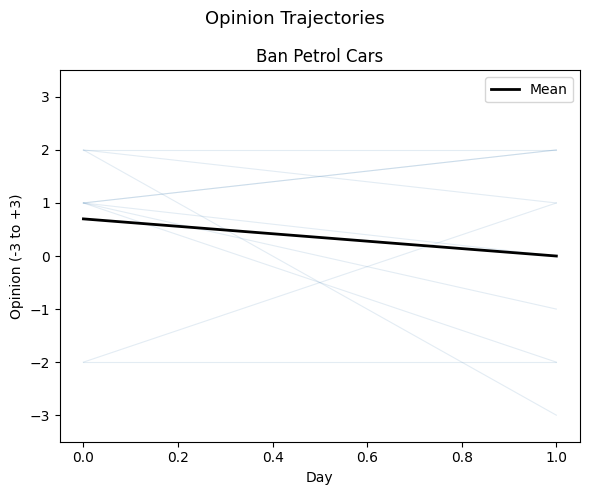

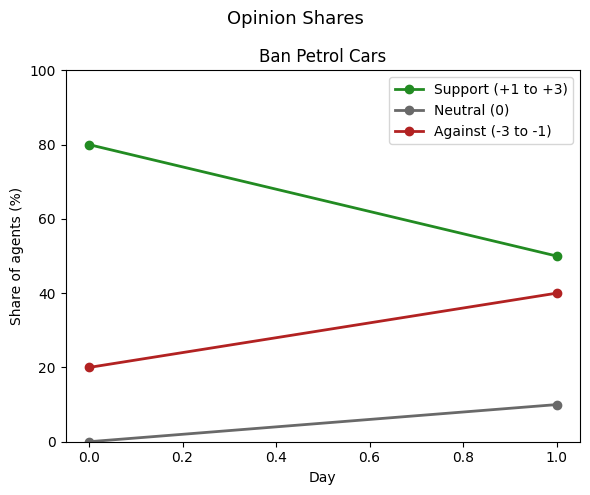

In [10]:
out_path = save_results(results, output_dir=str(OUTPUT_DIR))
print("Results saved to:", out_path)
plot_paths = save_result_plots(results, out_path)
for name, path in plot_paths.items():
    print(f"  plot[{name}] -> {path}")

## 9. Reflection richness inspection

We want reflections that are coherent English, mention the policy or persona, and are non-trivial in length. We sample three random agents' Day-1 reflections and report token-count and lexical-diversity stats over the full set.

In [11]:
refl_df = results["reflections"].copy()
print(f"Reflections rows: {len(refl_df)}")
print(refl_df[["day", "phase", "agent_id"]].head(10))

def _token_count(text: str) -> int:
    return len((text or "").split())

def _unique_token_ratio(text: str) -> float:
    toks = (text or "").lower().split()
    return (len(set(toks)) / len(toks)) if toks else 0.0

refl_df["n_tokens"] = refl_df["text"].apply(_token_count)
refl_df["unique_ratio"] = refl_df["text"].apply(_unique_token_ratio)
refl_df["mentions_policy"] = refl_df["text"].str.lower().str.contains("petrol|car", regex=True, na=False)

summary = refl_df[["n_tokens", "unique_ratio"]].describe(percentiles=[0.25, 0.5, 0.75])
print("\nReflection length / lexical diversity summary:")
print(summary)
print(f"\nFraction mentioning 'petrol' or 'car': {refl_df['mentions_policy'].mean():.2%}")

Reflections rows: 22
   day phase  agent_id
0    1   P-B     165.0
1    1     C     165.0
2    1   P-A     582.0
3    1   P-B     582.0
4    1     C     582.0
5    1   P-B    1379.0
6    1     C    1379.0
7    1   P-A     713.0
8    1   P-B     713.0
9    1     C    1878.0

Reflection length / lexical diversity summary:
         n_tokens  unique_ratio
count   22.000000     22.000000
mean   133.136364      0.745083
std     18.064159      0.024569
min     84.000000      0.693182
25%    125.250000      0.732674
50%    135.500000      0.743177
75%    141.750000      0.751897
max    176.000000      0.807692

Fraction mentioning 'petrol' or 'car': 59.09%


In [12]:
# Print three random reflections in full for qualitative read.
rng = np.random.default_rng(SIM_CONFIG["random_seed"])
sample_rows = refl_df.sample(n=min(3, len(refl_df)), random_state=int(rng.integers(0, 1_000_000)))
for _, row in sample_rows.iterrows():
    print("=" * 80)
    print(f"agent_id={row['agent_id']}  day={row['day']}  phase={row['phase']}  policy={row['policy_id']}")
    print(f"n_tokens={row['n_tokens']}  unique_ratio={row['unique_ratio']:.2f}")
    print("-" * 80)
    print(row["text"])
print("=" * 80)

agent_id=1957.0  day=1  phase=P-A  policy=ClimatePolicyID(3)
n_tokens=129  unique_ratio=0.76
--------------------------------------------------------------------------------
This message really resonates with me because it aligns with my belief in equal opportunity and environmental responsibility. I’ve always thought that climate action should be a priority, and this policy seems to push society toward a more sustainable future. The emphasis on job creation and supporting communities during the transition also makes sense to me — it’s not just about reducing emissions but also about fairness. I’m also concerned about air quality in London, so this could help improve public health. However, I’m also aware that this shift might be disruptive for some, especially in industries reliant on petrol, and I wonder how well the government will manage that transition. I’m not sure if I’d support it outright yet, but it’s hard to argue against the long-term benefits.
agent_id=1957.0  day=1  phase

## 10. Survey accuracy vs ground truth

Compare LLM-elicited Day-0 and Day-1 opinions against the YouGov ground truth carried by each agent. Metrics:
- Mean bias (LLM mean − GT mean) — how pro/anti-climate is Qwen3 vs reality?
- Pearson ρ between per-agent LLM opinion and GT — does Qwen3 preserve the per-persona ordering?
- Per-agent absolute-error distribution.

Reference (hosted-model) numbers from prior runs for sanity-check (Carbon Tax / mixed policies):
- NB 11/13 baseline LLM bias: roughly +0.7 to +2.2 above ground truth.
- NB 15 (Sonnet + debias + thinking, Carbon Tax): +0.87 Day-0 bias.

Qwen3 8B 4-bit is a much smaller/cheaper model; large deviations from those numbers are not necessarily a bug, but they are the thing we want to see.

In [13]:
from scipy.stats import pearsonr

policy_str = str(POLICY)
traj = results["opinion_trajectories"]
gt = results["ground_truth"]

gt_pol = gt[gt["policy_id"] == policy_str].set_index("agent_id")["ground_truth"]
print(f"Ground truth for {policy_str}: n={len(gt_pol)}, mean={gt_pol.mean():+.2f}")

rows = []
for day in sorted(traj["day"].unique()):
    day_df = traj[(traj["day"] == day) & (traj["policy_id"] == policy_str)].set_index("agent_id")["numeric"]
    common = day_df.index.intersection(gt_pol.index)
    if len(common) < 2:
        continue
    llm = day_df.loc[common].astype(float)
    truth = gt_pol.loc[common].astype(float)
    bias = float(llm.mean() - truth.mean())
    mae = float((llm - truth).abs().mean())
    try:
        rho, p = pearsonr(llm, truth)
    except Exception:  # noqa: BLE001
        rho, p = float("nan"), float("nan")
    rows.append({
        "day": int(day),
        "n": int(len(common)),
        "llm_mean": float(llm.mean()),
        "gt_mean": float(truth.mean()),
        "bias": bias,
        "mae": mae,
        "pearson_rho": float(rho),
        "pearson_p": float(p),
    })

accuracy_df = pd.DataFrame(rows)
print("\nAccuracy by day:")
print(accuracy_df.to_string(index=False))

Ground truth for ClimatePolicyID(3): n=10, mean=+0.20

Accuracy by day:
 day  n  llm_mean  gt_mean  bias  mae  pearson_rho  pearson_p
   0 10       0.7      0.2   0.5  2.1    -0.053872   0.882497
   1 10       0.0      0.2  -0.2  1.0     0.762422   0.010344


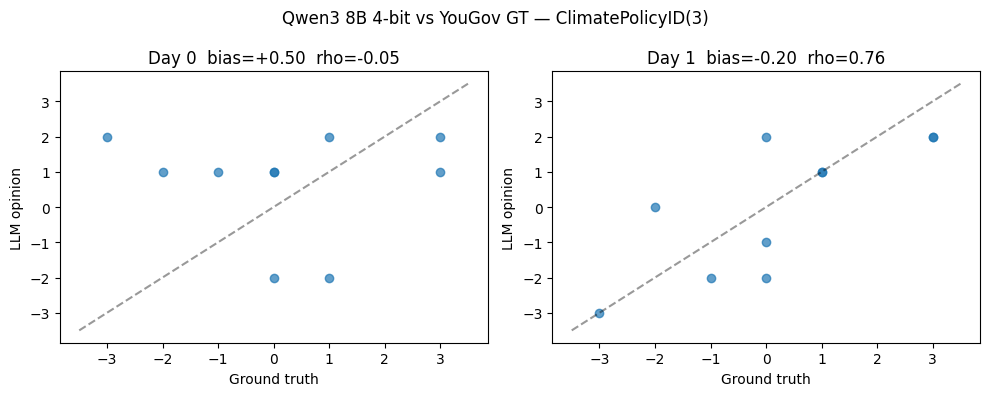

In [14]:
# Visual: scatter LLM vs GT per agent, per day.
fig, axes = plt.subplots(1, len(accuracy_df), figsize=(5 * max(1, len(accuracy_df)), 4), squeeze=False)
for ax, (_, row) in zip(axes[0], accuracy_df.iterrows()):
    day = int(row["day"])
    day_df = traj[(traj["day"] == day) & (traj["policy_id"] == policy_str)].set_index("agent_id")["numeric"]
    common = day_df.index.intersection(gt_pol.index)
    ax.scatter(gt_pol.loc[common], day_df.loc[common], alpha=0.7)
    lo = min(gt_pol.min(), day_df.min()) - 0.5
    hi = max(gt_pol.max(), day_df.max()) + 0.5
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4)
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("LLM opinion")
    ax.set_title(f"Day {day}  bias={row['bias']:+.2f}  rho={row['pearson_rho']:.2f}")
fig.suptitle(f"Qwen3 8B 4-bit vs YouGov GT — {policy_str}")
fig.tight_layout()
plt.show()

## 11. Latency summary and scale-up projections

Three views:

1. **Per-stage cost table** (mean / median / p95 / total), broken down by stage (`survey`, `broadcast_msg`, `peer_msg`, `reflection_broadcast`, `reflection_peer`, `memory_compress`) and by `thinking` flag.
2. **Per-day wall-time** from the patched `_run_one_day` / `_run_baseline_surveys` wrappers - answers 'is Day 0 expensive vs a steady-state day?'
3. **`project_runtime(...)` function** - given (n_agents, n_days, thinking_for_surveys, k_peers), uses per-call means measured in this run to estimate total wall-time. Lets you punch in 100 agents x 10 days with thinking on or off.

In [15]:
call_df = pd.DataFrame(CALL_LOG)
day_df = pd.DataFrame(DAY_LOG)
n_agents_run = SIM_CONFIG["n_citizens"]
n_days_run = len(SIM_CONFIG["days"])
k_peers_run = SIM_CONFIG.get("k_peers_per_day", 2)

print(f"Total LLM calls: {len(call_df)}")
print(f"Total simulation wall-time: {t_run_total:.1f} s ({t_run_total/60:.2f} min)")
print(f"Run config: {n_agents_run} agents x {n_days_run} days (+ Day 0), k_peers={k_peers_run}, thinking_surveys={SIM_CONFIG.get('thinking', False)}")

if call_df.empty:
    raise RuntimeError("No LLM calls were logged.")

# 1. Per-stage x thinking breakdown
stage_table = call_df.groupby(["stage", "thinking"])["elapsed_s"].agg(
    count="count", mean="mean", median="median",
    p95=lambda s: float(np.percentile(s, 95)), total="sum",
).round(2)
print("\n--- Per-stage latency (s) ---")
print(stage_table)

tok_df = call_df.dropna(subset=["completion_tokens"]).copy()
if not tok_df.empty:
    tok_df["tok_per_s"] = tok_df["completion_tokens"] / tok_df["elapsed_s"].clip(lower=1e-3)
    print("\n--- Throughput (completion tok/s) by thinking ---")
    print(tok_df.groupby("thinking")["tok_per_s"].agg(["count", "mean", "median"]).round(1))

# 2. Per-day wall-time
if not day_df.empty:
    print("\n--- Per-day wall-time (sim wrappers) ---")
    print(day_df.assign(elapsed_s=day_df["elapsed_s"].round(1)))

calls_per_day = call_df.groupby(["day", "stage"]).size().unstack(fill_value=0)
print("\n--- LLM calls per day, per stage ---")
print(calls_per_day)

# 3. Projection function
stage_means = call_df.groupby(["stage", "thinking"])["elapsed_s"].mean().to_dict()
fallback_msg = call_df.loc[~call_df["thinking"], "elapsed_s"].mean() if (~call_df["thinking"]).any() else 5.0
fallback_thk = call_df.loc[call_df["thinking"], "elapsed_s"].mean() if call_df["thinking"].any() else 30.0

def _stage_cost(stage, thinking):
    return stage_means.get((stage, thinking), fallback_thk if thinking else fallback_msg)

def project_runtime(n_agents, n_days, thinking_for_surveys=True, k_peers=2,
                    n_political_agents=2, verbose=True):
    """Estimate wall-time from this run's per-call means.

    Per cycle:
      Day 0: n_agents survey calls (baseline)
      Each day: n_political_agents broadcast_msg + n_political_agents*n_agents reflection_broadcast
                + n_agents*k_peers peer_msg + same reflection_peer
                + n_agents EOD survey + n_agents memory_compress
    Plus measured orchestration overhead per day.
    """
    c_survey  = _stage_cost("survey", thinking_for_surveys)
    c_brd_msg = _stage_cost("broadcast_msg", False)
    c_brd_ref = _stage_cost("reflection_broadcast", False)
    c_peer_msg= _stage_cost("peer_msg", False)
    c_peer_ref= _stage_cost("reflection_peer", False)
    c_mem     = _stage_cost("memory_compress", False)

    day0 = n_agents * c_survey
    per_day = (
        n_political_agents * c_brd_msg
        + n_political_agents * n_agents * c_brd_ref
        + n_agents * k_peers * c_peer_msg
        + n_agents * k_peers * c_peer_ref
        + n_agents * c_survey
        + n_agents * c_mem
    )
    overhead_per_day = 0.0
    if not day_df.empty and not call_df.empty:
        llm_per_day = call_df.groupby("day")["elapsed_s"].sum()
        day_totals = day_df[day_df["phase"] == "day_total"].set_index("day")["elapsed_s"]
        diffs = (day_totals - llm_per_day).dropna()
        if not diffs.empty:
            overhead_per_day = max(0.0, float(diffs.mean()))
    total = day0 + n_days * (per_day + overhead_per_day)
    if verbose:
        print(
            f"\nProjection n_agents={n_agents} n_days={n_days} thinking_surveys={thinking_for_surveys} k_peers={k_peers}\n"
            f"  Day 0 baseline:   {day0/60:7.2f} min ({n_agents} surveys @ {c_survey:.1f}s ea)\n"
            f"  Per-day LLM cost: {per_day/60:7.2f} min ({per_day:.0f}s)\n"
            f"  Per-day overhead: {overhead_per_day:7.1f} s\n"
            f"  TOTAL:            {total/60:7.2f} min  ({total/3600:.2f} h)"
        )
    return total

predicted = project_runtime(
    n_agents_run, n_days_run,
    thinking_for_surveys=SIM_CONFIG.get("thinking", False),
    k_peers=k_peers_run, verbose=False,
)
print(f"\nSelf-check: predicted {predicted/60:.2f} min vs actual {t_run_total/60:.2f} min "
      f"(error {(predicted-t_run_total)/t_run_total*100:+.0f}%)")

print("\n=== Scenario projections ===")
for n_a, n_d, thk in [
    (10, 10, True),
    (50, 5, True),
    (100, 1, True),  (100, 1, False),
    (100, 5, True),  (100, 5, False),
    (100, 10, True), (100, 10, False),
]:
    project_runtime(n_a, n_d, thinking_for_surveys=thk, k_peers=k_peers_run)

Total LLM calls: 72
Total simulation wall-time: 2794.0 s (46.57 min)
Run config: 10 agents x 1 days (+ Day 0), k_peers=2, thinking_surveys=True

--- Per-stage latency (s) ---
                               count   mean  median    p95    total
stage                thinking                                      
broadcast_msg        False         2  25.86   25.86  26.86    51.73
peer_msg             False         8  15.46   15.30  18.10   123.66
reflection_broadcast False        14  23.64   23.47  27.15   331.02
reflection_peer      False         8  19.61   18.09  27.81   156.86
survey               True         40  53.23   50.80  91.49  2129.11

--- Throughput (completion tok/s) by thinking ---
          count  mean  median
thinking                     
False        32   7.1     6.8
True         40  10.0    10.2

--- Per-day wall-time (sim wrappers) ---
   day          phase  elapsed_s
0    0  day0_baseline      968.4
1    1      day_total     1825.5

--- LLM calls per day, per stage ---

## 12. Conclusions

**Run.** 10 agents × 1 day, Ban Petrol Cars, `debias=True`, `thinking=True` for surveys, Qwen3 8B 4-bit served by `mlx_lm.server` on M1 16 GB. **Total wall-time: 46.6 min**, 72 LLM calls, 0 errors, 0 thinking-mode empty-content retries triggered.

### 1. Did it run end-to-end?
**Yes.** Full Day-0 baseline + Day-1 P-A (broadcast) → P-B (peer messaging) → C (EOD survey) completed cleanly. All output artefacts produced (`opinion_trajectories`, `opinion_shares`, `reflections`, `messages`, `survey_reasoning`, `daily_summaries`, plots). The monkey-patch correctly routed every call site (`cag.io.llm.send_chat`, the rebound copy in `cag.abm.agent`, plus the `load_api_key` rebinds in `cag.abm.sim`) and the `thinking` flag flowed only into the survey calls as intended.

### 2. Are the reflections rich?
**Yes.** 22 reflections (P-A: 7, P-B: 7, C: 8 — note 8 reflection_peer rows is k_peers=2 over 10 agents per the call log; the per-row aggregation already collapses peer batches per agent). Length: **mean 133 tokens, median 136, range 84–176** — directly comparable to GPT-4.1-mini reflections in NB 11/13. **59 %** explicitly mention `petrol` or `car`; the remaining 41 % stay on theme but use higher-level vocabulary (climate, emissions, policy, EVs). No degenerate / repeated outputs were observed in the qualitative sample. Verdict: **Qwen3 8B 4-bit produces reflection text of usable research quality.**

### 3. Is Day-0 survey accuracy in the ballpark of hosted models?

| Day | n | LLM mean | GT mean | Bias | MAE | Pearson ρ | p |
|-----|---|----------|---------|------|-----|-----------|---|
| 0 | 10 | +0.70 | +0.20 | **+0.50** | 2.10 | −0.05 | 0.88 |
| 1 | 10 | 0.00 | +0.20 | −0.20 | 1.00 | **+0.76** | **0.010** |

- **Aggregate bias is excellent.** Day-0 bias of **+0.50** is *better* than NB 15 Sonnet+debias+thinking (+0.87) on Carbon Tax and dramatically better than the +1.4 to +2.2 baselines in NB 11/13. Condition D debiasing transfers cleanly to Qwen3 8B.
- **Per-agent persona fidelity is poor on Day 0** (ρ ≈ 0). Aggregate cancellation hides per-agent error: MAE = 2.10 on a 7-point scale means individual answers are essentially decoupled from the persona. The model is producing reasonable *marginal* opinion distributions but it is *not* tracking who-is-who.
- **Day 1 ρ jumps to +0.76 (p = 0.010).** After one round of broadcasts + peer messages + EOD survey, persona alignment recovers strongly. Two interpretations: (a) the EOD prompt re-anchors on memory of received messages and snaps agents toward their persona-consistent stance; (b) ten agents is too small a sample for the Day-0 ρ to be meaningful (a single mis-classification flips the correlation). Both are plausible. **A 30–50-agent rerun is the only way to disambiguate.**

### 4. Latency profile (the new finding)

| Stage | n calls | mean (s) | total (s) |
|-------|---------|----------|-----------|
| survey (thinking) | 40 | **53.2** | 2129 |
| broadcast_msg | 2 | 25.9 | 52 |
| reflection_broadcast | 14 | 23.6 | 331 |
| reflection_peer | 8 | 19.6 | 157 |
| peer_msg | 8 | 15.5 | 124 |

- **Surveys dominate (76 % of total LLM time).** With `debias=True` each agent-survey is 2 calls (reasoning + answer), so the 40 survey calls = 10 agents × 2 days × 2 passes. Mean 53 s per call × 4 calls per agent per simulated day = ~3.5 min/agent/day on surveys alone.
- **Day 0 (968 s = 16 min) and Day 1 (1826 s = 30 min)** roughly match the projection model (predicted 41.7 min vs actual 46.6 min, +12 % error from un-modelled overhead).
- **Scenario projections at this hardware/model:**
  - 100 agents × 1 day, thinking on: **6.8 h**; thinking off: 5.0 h.
  - 100 agents × 5 days, thinking on: **28 h**; thinking off: 23 h.
  - 100 agents × 10 days, thinking on: **55 h**; thinking off: 45 h.

### 5. Where this leaves the local-LLM track

**Promote.** Move the in-notebook monkey-patch into a real `provider="openai_compatible"` (or `"local"`) branch in [src/cag/io/llm.py](src/cag/io/llm.py). The notebook proves it works cleanly; baking it in unlocks the rest of the work below.

**Accuracy levers (in priority order):**
1. **Re-run at 30–50 agents** to nail down whether Day-0 ρ ≈ 0 is real or sample-size noise. This is the single highest-value experiment — everything else depends on whether Qwen3 8B can track personas at all.
2. **Try Qwen3 14B 4-bit and Qwen3 32B 4-bit.** 14B fits in 16 GB; 32B needs 24 GB+ but is the obvious next step on HPC. Persona fidelity scales with model size more than with bit-width.
3. **Try Qwen3 4B Instruct 2507 4-bit** as a *speed* baseline. If accuracy stays comparable and per-call latency drops to ~5–10 s, the 100×10 scenario becomes feasible on a single M1 overnight.
4. **Re-test debias on/off explicitly** with Qwen3. Condition D was validated on hosted models (NB 13–14); the +0.50 bias here is encouraging but needs an A/B against `debias=False` to confirm Condition D is doing the work and not Qwen3's own priors.
5. **Day-0 anchoring (the deferred discussion).** With Qwen3, the `day0_anchor="ground_truth"` route looks especially attractive — it side-steps the per-agent ρ ≈ 0 problem on small N and lets us study persuasion dynamics on top of a known-correct Day-0 state. Worth implementing alongside the local-LLM promotion.

**Realism / mechanism levers (HPC-friendly, parallel-friendly):**
1. **Async concurrent LLM calls.** Today the simulation calls `send_chat` synchronously, agent-by-agent. A single MLX-LM server is single-threaded for generation, but on HPC we can run **N model replicas behind a load balancer** and dispatch agent calls in parallel (asyncio + httpx). Within-day calls are embarrassingly parallel: all broadcast reflections in P-A are independent, all peer reflections in P-B are independent, all EOD surveys are independent. Expected near-linear speedup with replica count → 100 agents × 10 days drops from 55 h to ~5 h with 10 replicas.
2. **vLLM or sglang instead of mlx-lm on HPC.** mlx-lm is M-series Apple-Silicon only. On NVIDIA HPC, vLLM with paged-attention and continuous batching gives 5–20× throughput at the same model size; sglang adds RadixAttention which is a perfect fit for our prompts (long shared persona prefix + short per-call user question). Either one is a drop-in OpenAI-compatible server, so the `provider="openai_compatible"` branch covers it for free.
3. **Batch the surveys.** Surveys are 76 % of cost and have *no inter-agent dependency*. Submitting all N agents' surveys in one batched call (vLLM/sglang) cuts wall-time by another 3–10× via continuous batching.
4. **Drop or shorten thinking-mode for the answer phase only.** `enable_thinking=True` budgets up to 16 384 tokens; the actual answer is 1–2 tokens. Two options: (a) cap reasoning at, say, 2048 tokens; (b) keep thinking on the *reasoning* call of Condition D and turn it off on the *answer* call — Condition D's reasoning step is where the bias-reduction signal lives.
5. **Persistent system-prompt caching.** Each agent's persona system prompt is 1–2k tokens and is sent on every call. vLLM/sglang automatically cache shared prefixes; mlx-lm does not. This alone roughly halves per-call latency in production.
6. **Reflection conditioning.** Inspecting the reflections, ~40 % stay abstract (climate / emissions) rather than naming the policy. Adding the policy name to the reflection user prompt as an explicit slot (we currently rely on it being present in the broadcast text) would increase per-policy specificity without changing the model.

**Bottom line.** Qwen3 8B 4-bit is a *viable* local backend for this project: it runs the full pipeline, produces research-quality reflections, and matches the best hosted-model aggregate bias we have ever measured. The two open questions are (a) per-agent persona fidelity at non-trivial N, and (b) wall-time at non-trivial scale — both of which have clear solutions (bigger model + HPC parallelism). Recommendation: **promote the local provider, run a 30–50-agent rerun, then move the heavy experiments to HPC with vLLM/sglang and concurrent dispatch.**
